# SPIKE

This library is being designed to simulate neuron responses, creating neuron clusters, and simulating the propagation through the neuron simulator.

**Goals:**
1. Accurately model neurons.
2. Accurately model synapse.
3. Develop a plasticity learning model.
4. Develop an CPU/GPU accelerator.

It's being designed as a _discrete_ simulator with a discretized time domain.  The units are in `ms` and `mV` for milliseconds and millivolts - though, it's better to think of it simply as a time quanta.

This means the default simulations are incredibly slow.  If the model ends up working well, it will be accelerated.

**What's not done.**

Well, most of it.  There is quite a long list of attributes which can be added which are either inhibatory/excitatory on the neurons and synapse.  In addition to that; the dendrite is a simple summation dendrite, a lot of information can be encoded into a response encoding vector.

Once all of those are completed, we can create a proper model.

The first objective will be to create a neuron model which can act as a real-time fourier analysis tool

# Neurons

We're going to create 3 differet neurons, and then generate an impule against them to visualize the spike train

In [39]:
from math import cos, tau
from pprint import pprint
from spike.v1 import (
  DefaultRecvNeuronModel,
  DefaultDataNeuronModel,
  DefaultSendNeuronModel,
)
from spike.v1.plot.dumb_plot1 import animate_neuron

## "Recv" neurons.

In this case, a "recv" neuron is essentially acting as a "sensor neuron".

We will show a plot for one cycle.

Neuron(_Neuron__counter=count(9),
       id=8,
       dendrite=Dendrite(),
       membrane=Membrane(resting_potential=-70.0,
                         firing_potential=-55.0,
                         reset_potential=-70.0,
                         potential_curr=-70.0,
                         potential_prev=-70.0,
                         refractory_model=RefractoryModel(amplitude=8.0,
                                                          kernel=RefractoryKernel(tau=4,
                                                                                  tau_constant=0.7788007830714049),
                                                          potential=0.0),
                         spike=False),
       axon=Axon(delay=0, fired=False, output=False),
       logging=False)


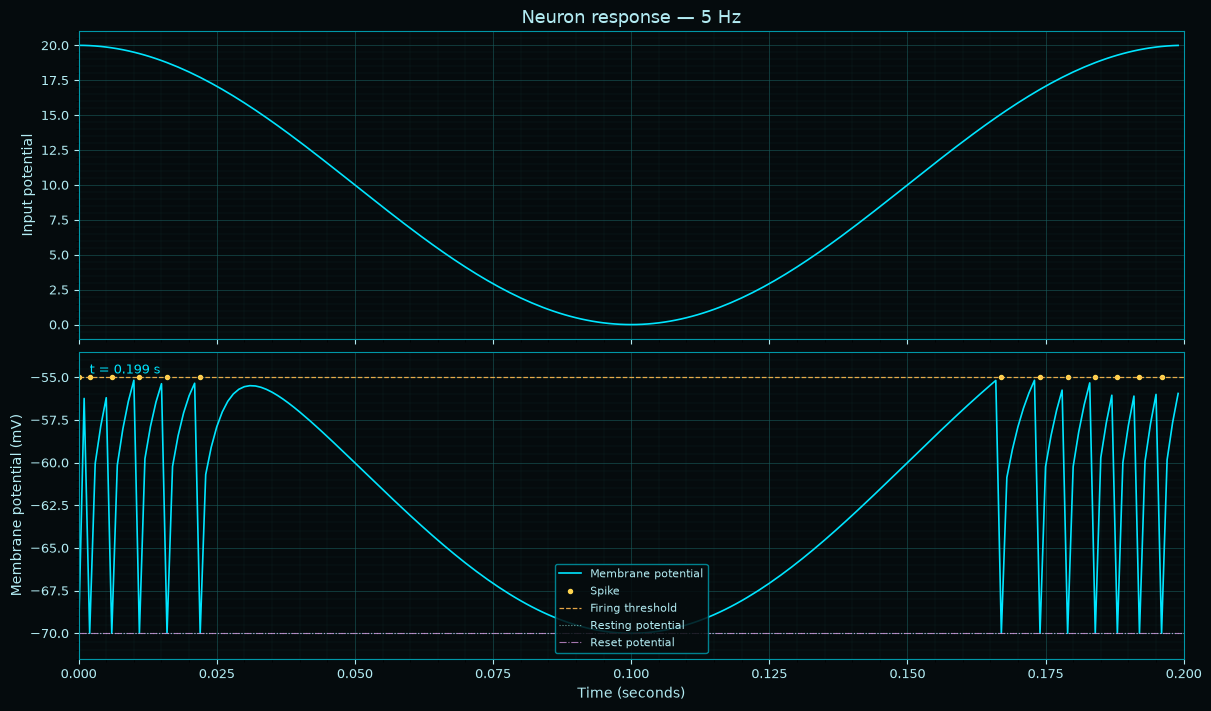

In [40]:
recv_neuron = DefaultRecvNeuronModel.random_neuron()
pprint(recv_neuron)

animate_neuron(
    recv_neuron,
    gain=20.0,
    frequency_hz=5.0,
    duration_s=0.2,
    dt_s=0.001,
    plot_every=10,
    interval_s=0.01,
)

## "Data" neurons.

The data neurons have a far more extensive randomization gammut for the parameterization.  Some of them will be completely insane, as the model does not yet have a refined notion of sanity - neither do the neruons have a memory change model in them.

You may also notice the spike does not occur at the peak, this is due to the delay parameters in the neuron model.

Neuron(_Neuron__counter=count(10),
       id=9,
       dendrite=Dendrite(),
       membrane=Membrane(resting_potential=-69.46291435364343,
                         firing_potential=-62.85638759293384,
                         reset_potential=-76.57203521180904,
                         potential_curr=-69.46291435364343,
                         potential_prev=-69.46291435364343,
                         refractory_model=RefractoryModel(amplitude=19.230164862203374,
                                                          kernel=RefractoryKernel(tau=8,
                                                                                  tau_constant=0.8824969025845955),
                                                          potential=0.0),
                         spike=False),
       axon=Axon(delay=0, fired=False, output=False),
       logging=False)


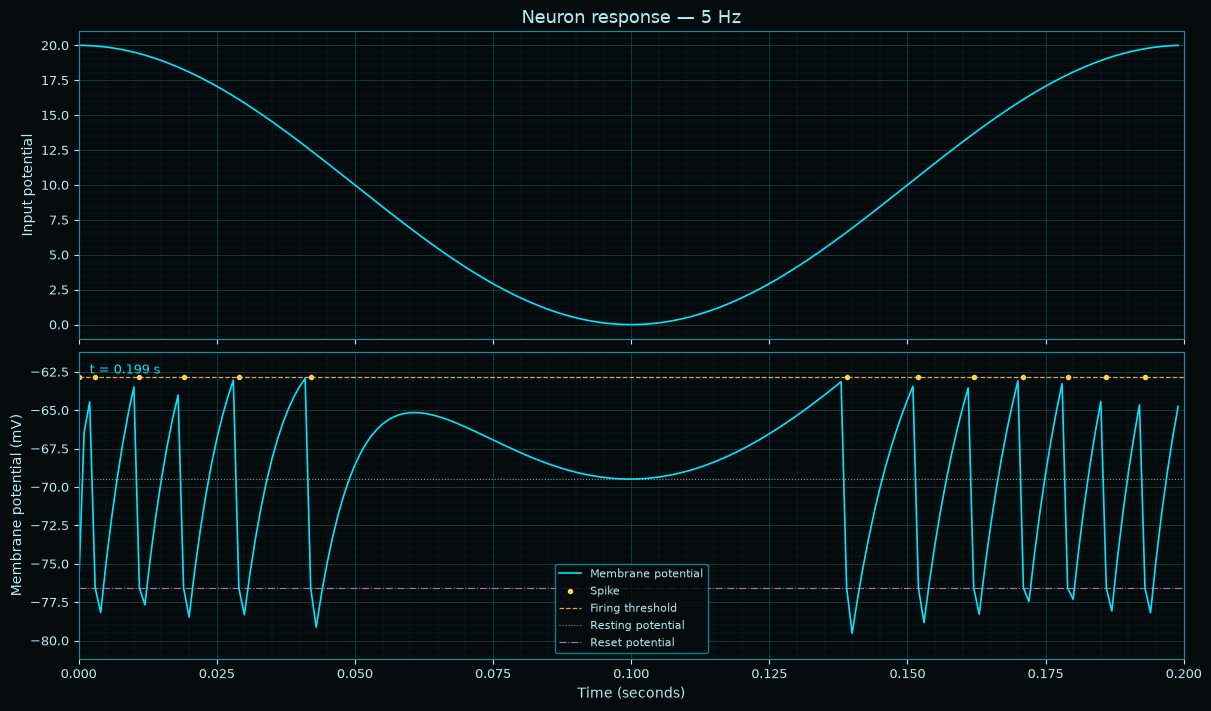

In [41]:
data_neuron = DefaultDataNeuronModel.random_neuron()
pprint(data_neuron)

animate_neuron(
    data_neuron,
    gain=20.0,
    frequency_hz=5.0,
    duration_s=0.2,
    dt_s=0.001,
    plot_every=10,
    interval_s=0.01,
)

## Send Neurons

The "send" neuron refers to notion it is a termination neuron for a cluster of neurons.  Thusly, it has different statistical properties than a computational neuron.

Neuron(_Neuron__counter=count(11),
       id=10,
       dendrite=Dendrite(),
       membrane=Membrane(resting_potential=-70.40696291169365,
                         firing_potential=-62.90702455315885,
                         reset_potential=-78.18315399558998,
                         potential_curr=-70.40696291169365,
                         potential_prev=-70.40696291169365,
                         refractory_model=RefractoryModel(amplitude=19.030927203532343,
                                                          kernel=RefractoryKernel(tau=16,
                                                                                  tau_constant=0.9394130628134758),
                                                          potential=0.0),
                         spike=False),
       axon=Axon(delay=0, fired=False, output=False),
       logging=False)


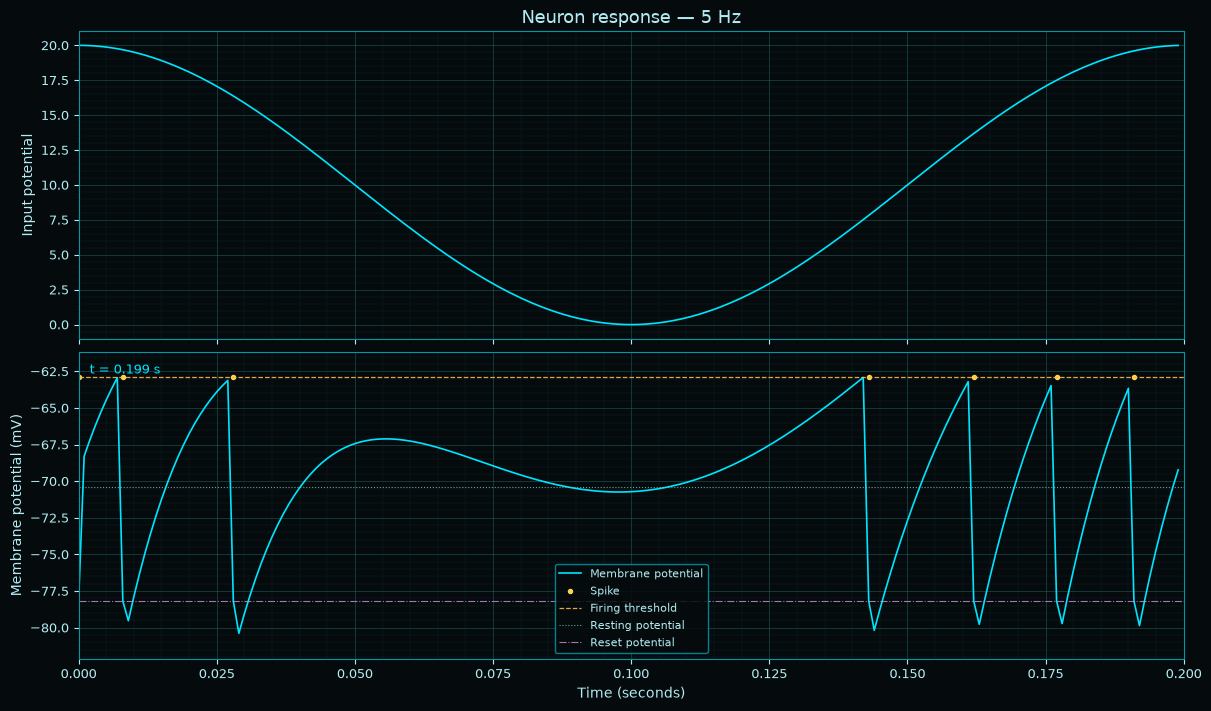

In [42]:
send_neuron = DefaultDataNeuronModel.random_neuron()
pprint(send_neuron)

animate_neuron(
    send_neuron,
    gain=20.0,
    frequency_hz=5.0,
    duration_s=0.2,
    dt_s=0.001,
    plot_every=10,
    interval_s=0.01,
)

# Synapse

The synapse would normally be attached to the neuron's AXON for firing potentials in a simulator.  But let's view what it would looke like if we attached a single synapse to a neuron. 

In [43]:
from spike.v1 import (
  DefaultRecvSynapseModel,
  DefaultDataSynapseModel,
  DefaultSendSynapseModel,
)
from spike.v1.plot.dumb_plot2 import animate_synapse_neuron

## "Recv" Synapse

In [44]:
recv_synapse  = DefaultRecvSynapseModel.random_synapse()

pprint(recv_neuron)
print("-" * 70)
pprint(recv_synapse)


Neuron(_Neuron__counter=count(11),
       id=8,
       dendrite=Dendrite(),
       membrane=Membrane(resting_potential=-70.0,
                         firing_potential=-55.0,
                         reset_potential=-70.0,
                         potential_curr=np.float64(-55.94565413248182),
                         potential_prev=np.float64(-57.647767850338425),
                         refractory_model=RefractoryModel(amplitude=8.0,
                                                          kernel=RefractoryKernel(tau=4,
                                                                                  tau_constant=0.7788007830714049),
                                                          potential=5.940719736139137),
                         spike=np.False_),
       axon=Axon(delay=0, fired=np.False_, output=np.False_),
       logging=False)
----------------------------------------------------------------------
Synapse(amplitude=6.505317994820706,
        delay=0,
        kernel

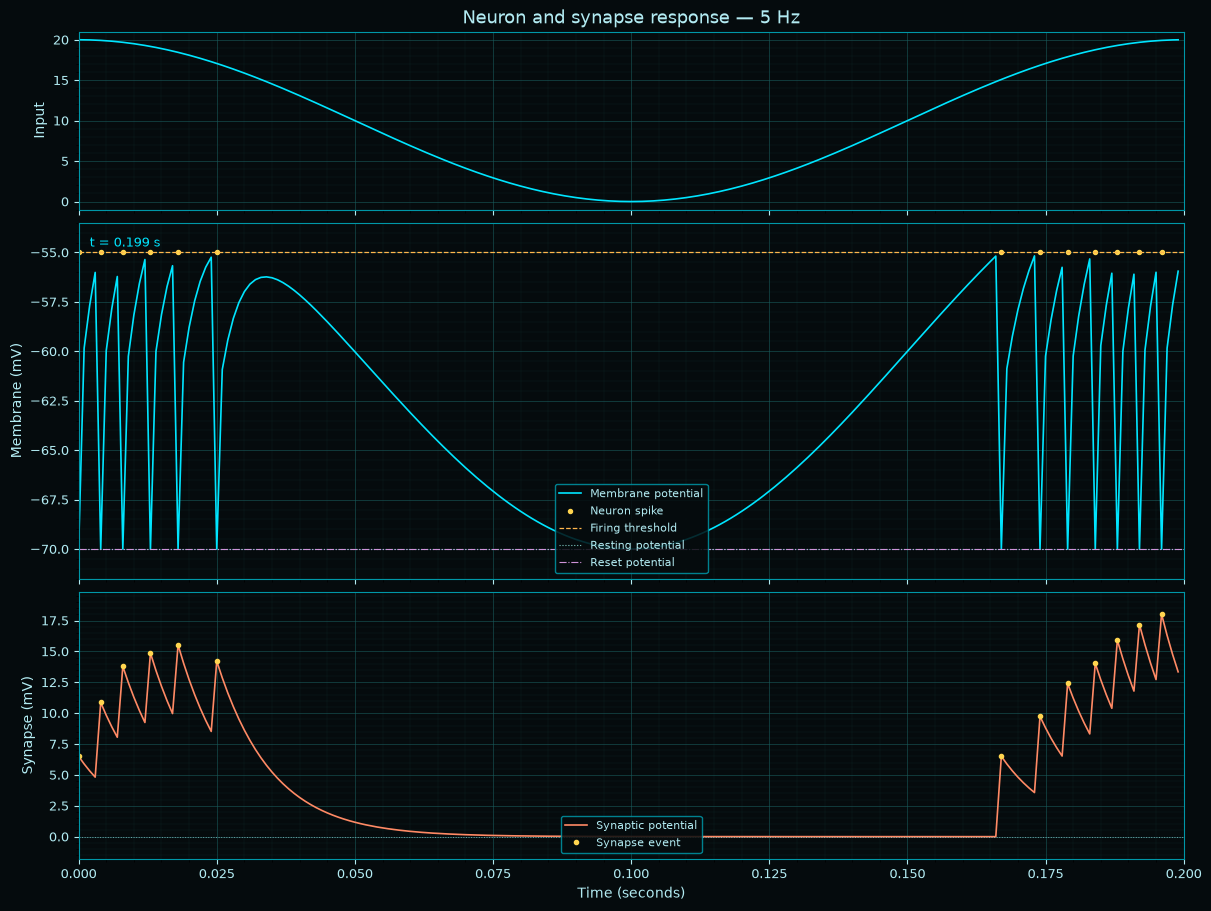

In [45]:
animate_synapse_neuron(
    recv_neuron,
    recv_synapse,
    gain=20.0,
    frequency_hz=5.0,
    duration_s=0.2,
    dt_s=0.001,
    plot_every=10,
    interval_s=0.01,
)

## Data Synapse

In [46]:
data_synapse = DefaultDataSynapseModel.random_synapse()

pprint(data_neuron)
print("-" * 70)
pprint(data_synapse)



Neuron(_Neuron__counter=count(11),
       id=9,
       dendrite=Dendrite(),
       membrane=Membrane(resting_potential=-69.46291435364343,
                         firing_potential=-62.85638759293384,
                         reset_potential=-76.57203521180904,
                         potential_curr=np.float64(-64.75056358578179),
                         potential_prev=np.float64(-66.80023174420403),
                         refractory_model=RefractoryModel(amplitude=19.230164862203374,
                                                          kernel=RefractoryKernel(tau=8,
                                                                                  tau_constant=0.8824969025845955),
                                                          potential=15.282714835795684),
                         spike=np.False_),
       axon=Axon(delay=0, fired=np.False_, output=np.False_),
       logging=False)
----------------------------------------------------------------------
Synapse(amplit

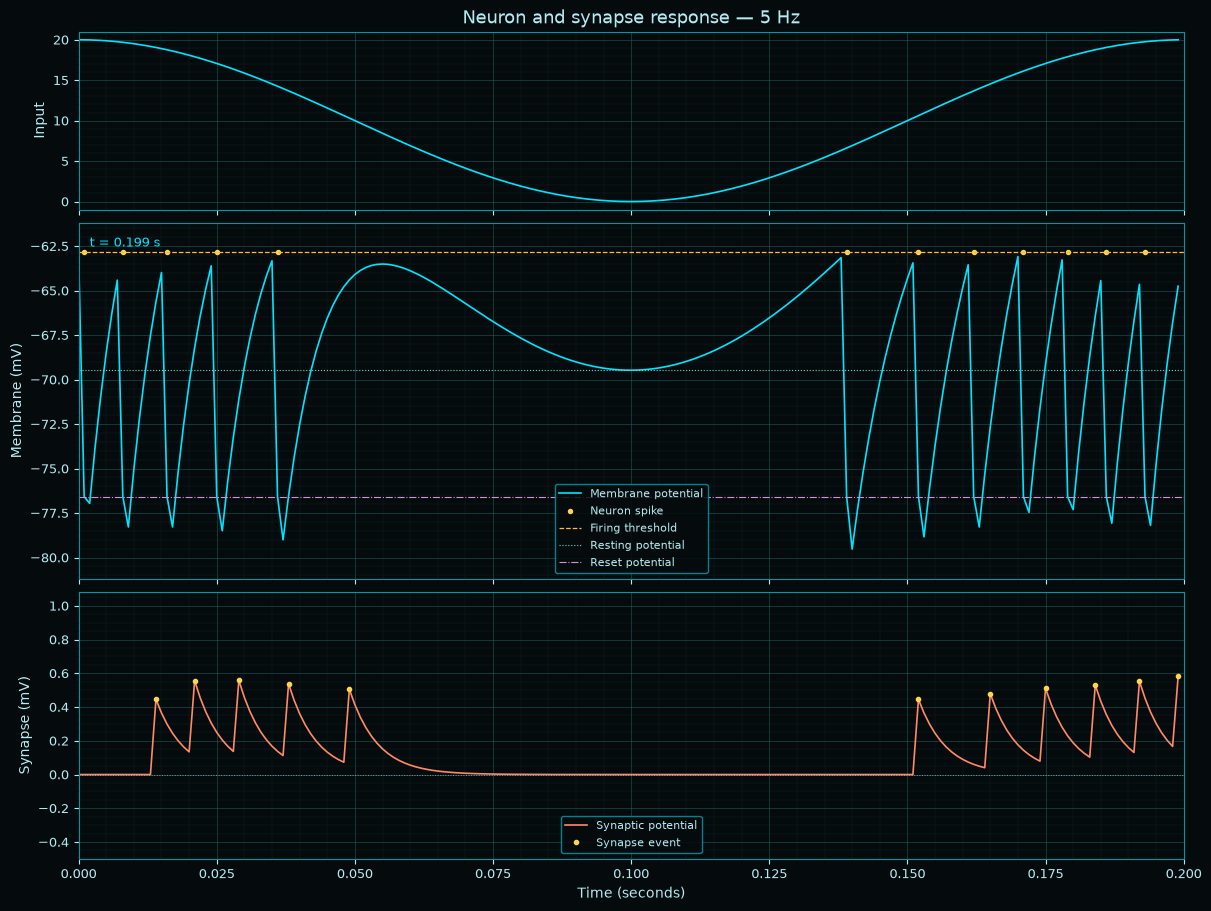

In [47]:
animate_synapse_neuron(
    data_neuron,
    data_synapse,
    gain=20.0,
    frequency_hz=5.0,
    duration_s=0.2,
    dt_s=0.001,
    plot_every=10,
    interval_s=0.01,
)

## Send Synapse

In [48]:
send_synapse = DefaultSendSynapseModel.random_synapse()

pprint(send_neuron)
print("-" * 70)
pprint(send_synapse)

Neuron(_Neuron__counter=count(11),
       id=10,
       dendrite=Dendrite(),
       membrane=Membrane(resting_potential=-70.40696291169365,
                         firing_potential=-62.90702455315885,
                         reset_potential=-78.18315399558998,
                         potential_curr=np.float64(-69.22614566905034),
                         potential_prev=np.float64(-70.45435875641476),
                         refractory_model=RefractoryModel(amplitude=19.030927203532343,
                                                          kernel=RefractoryKernel(tau=16,
                                                                                  tau_constant=0.9394130628134758),
                                                          potential=18.814248361014005),
                         spike=np.False_),
       axon=Axon(delay=0, fired=np.False_, output=np.False_),
       logging=False)
----------------------------------------------------------------------
Synapse(ampl

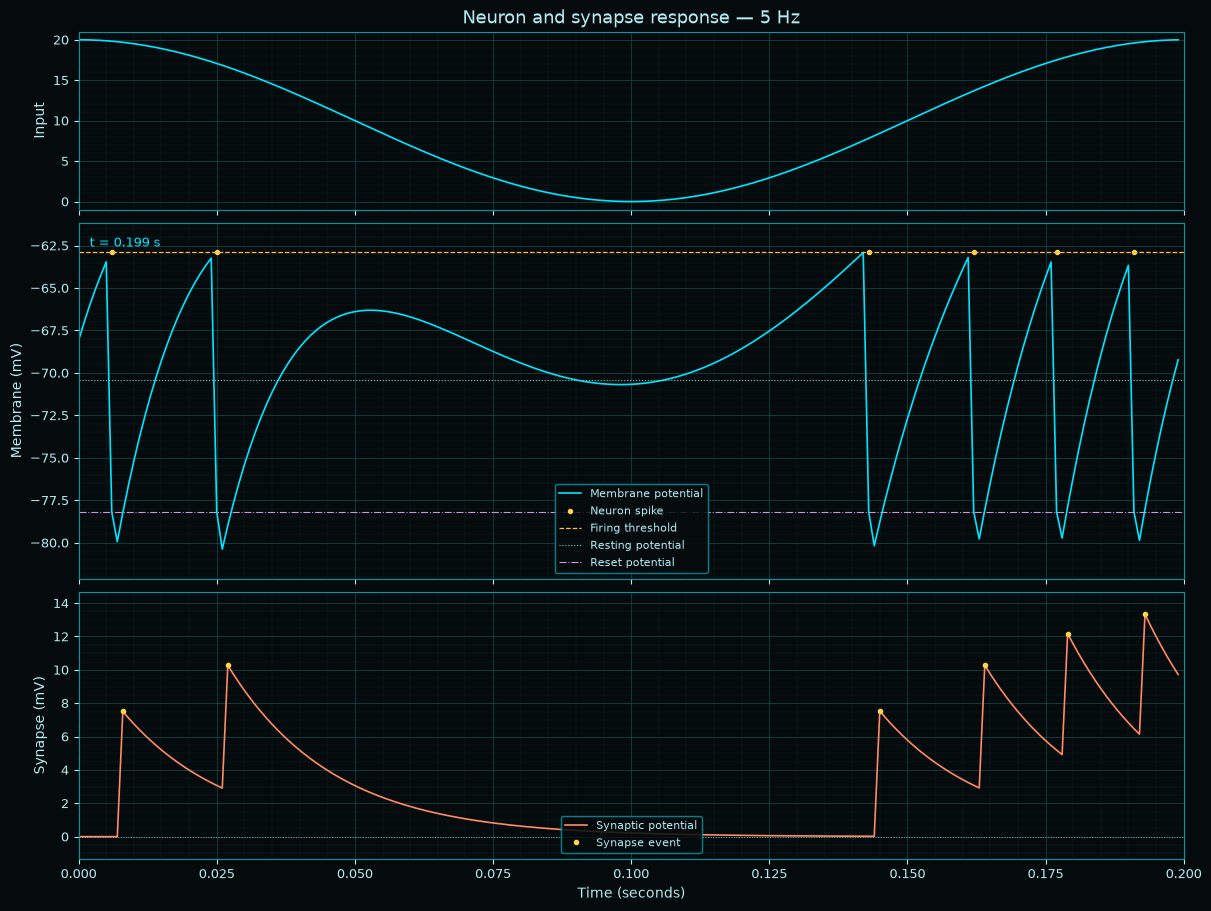

In [49]:
animate_synapse_neuron(
    send_neuron,
    send_synapse,
    gain=20.0,
    frequency_hz=5.0,
    duration_s=0.2,
    dt_s=0.001,
    plot_every=10,
    interval_s=0.01,
)